In [435]:
# importing libaries

# 1. To handle the data
import pandas as pd
import numpy as np

# 2. To visualize the data
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 3. To preprocess the data
from sklearn.preprocessing import StandardScaler , MinMaxScaler , LabelEncoder
from sklearn.impute import SimpleImputer , KNNImputer
# import iterative imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 4. machine learning 
from sklearn.model_selection import train_test_split , GridSearchCV , RandomizedSearchCV , cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, confusion_matrix, classification_report, roc_curve)
# for classification task
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier,RandomForestRegressor,GradientBoostingClassifier,VotingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
# Metrics
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report ,mean_absolute_error ,  r2_score , root_mean_squared_error
# ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [436]:
df=pd.read_csv("heart_disease_uci.csv")

In [437]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [438]:
df.shape

(920, 16)

In [439]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [440]:
print(f"Dataset shape: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nTarget variable (num) distribution:")
print(df['num'].value_counts().sort_index())

# Convert target to binary
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
print(f"\nBinary target distribution:")
print(df['target'].value_counts())
print(f"Class balance: {df['target'].value_counts(normalize=True)}")



Dataset shape: (920, 16)
Missing values:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

Data types:
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

Target variable (num) distribution:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Binary target distribution:
target
1    509
0    411
Name: count, dtype: int64
Class balance: target
1    0.553261
0    0.446739
Name: proportion, dtype: float64


<Axes: xlabel='age', ylabel='Count'>

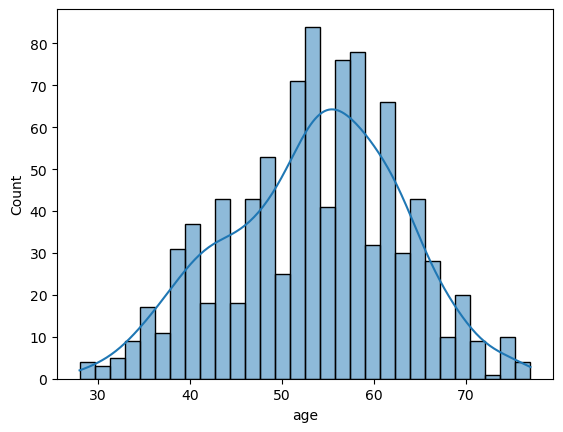

In [441]:
sns.histplot(data=df , x='age' , bins=30 , kde=True)

Mean: 53.51086956521739
Median: 54.0
Mode: 54


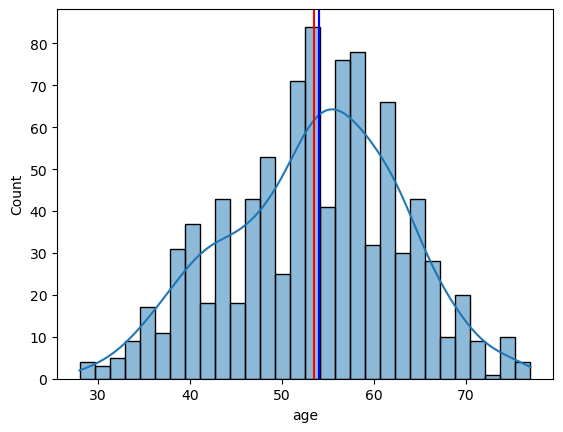

In [442]:
# plot the mean , median and mode of age column using sns
sns.histplot(df['age'], bins=30, kde=True)
plt.axvline(df['age'].mean(), color='red')
plt.axvline(df['age'].median(), color='green')
plt.axvline(df['age'].mode()[0], color='blue')

# print the value of mean , median and mode of age column
print("Mean:", df['age'].mean())
print("Median:", df['age'].median())
print("Mode:", df['age'].mode()[0])

In [443]:
# plot the histogram of age column using plotly and coloring this by sex
fig= px.histogram(data_frame=df ,x='age',color='sex')
fig.show()

In [444]:
# find the values of sex column
df['sex'].value_counts()

sex
Male      726
Female    194
Name: count, dtype: int64

In [445]:
# calculate the percentages of male and female value counts in the data
male_count = 726/len(df) * 100
female_count = 194/len(df) * 100
print (f"Male Percentage:{male_count:.2f} %")
print (f"Female Percentage:{female_count:.2f} %")
percentage_differ=(male_count-female_count)/female_count * 100
print(f"Males are {percentage_differ:.2f}% more then females in the data")

Male Percentage:78.91 %
Female Percentage:21.09 %
Males are 274.23% more then females in the data


In [446]:
# find the value counts of age column grouping by sex column
df.groupby('sex')['age'].value_counts()

sex     age
Female  54     15
        51     11
        62     10
        43      9
        48      9
               ..
Male    77      2
        28      1
        31      1
        33      1
        76      1
Name: count, Length: 91, dtype: int64

In [447]:
df['dataset'].value_counts()

dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

In [448]:
# value counts of dataset column grouped by sex
df.groupby('sex')['dataset'].value_counts()

sex     dataset      
Female  Cleveland         97
        Hungary           81
        Switzerland       10
        VA Long Beach      6
Male    Hungary          212
        Cleveland        207
        VA Long Beach    194
        Switzerland      113
Name: count, dtype: int64

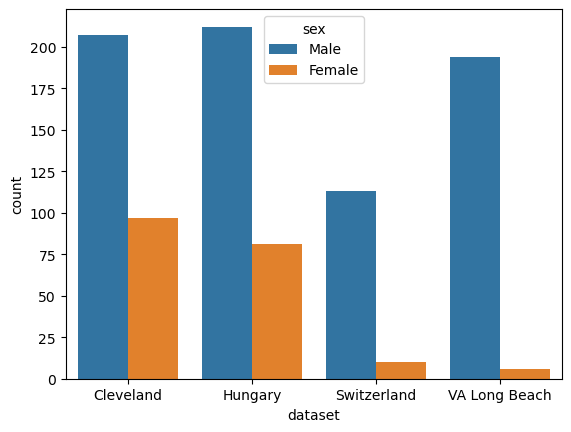

In [449]:
# plot the countplot of dataset column
sns.countplot(data=df , x='dataset' , hue='sex')
# make  a count plot using plotly 
fig=px.bar(df , x='dataset' , color='sex')
fig.show()

In [450]:
# Make a plot of age column using plotly and colouring this by dataset column
fig=px.histogram(data_frame=df ,x='age',color='dataset')
fig.show()

# print the mean , median and mode of age column grouped by dataset column
print("Mean of Data Set :" , df.groupby('dataset')['age'].mean())
print('-------------------------')
print("Median of Data Set :" , df.groupby('dataset')['age'].median())
print('-------------------------')
print("Mode of Data Set :" , df.groupby('dataset')['age'].agg(pd.Series.mode))
print('-------------------------')

Mean of Data Set : dataset
Cleveland        54.351974
Hungary          47.894198
Switzerland      55.317073
VA Long Beach    59.350000
Name: age, dtype: float64
-------------------------
Median of Data Set : dataset
Cleveland        55.5
Hungary          49.0
Switzerland      56.0
VA Long Beach    60.0
Name: age, dtype: float64
-------------------------
Mode of Data Set : dataset
Cleveland              58
Hungary                54
Switzerland            61
VA Long Beach    [62, 63]
Name: age, dtype: object
-------------------------


In [451]:
# value count of cp column
df['cp'].value_counts()

cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

<Axes: xlabel='cp', ylabel='count'>

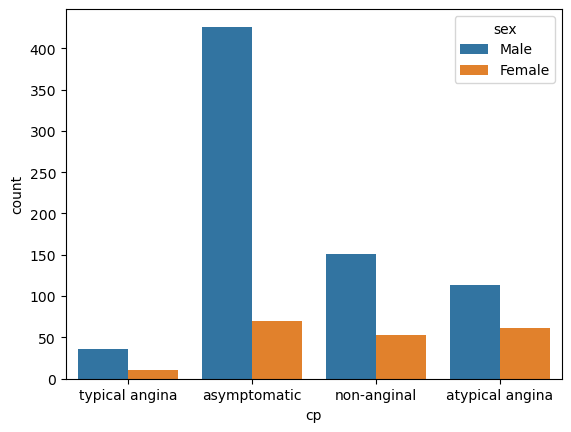

In [452]:
# count plot of cp column by sex column
sns.countplot(data=df , x='cp' , hue='sex')

In [453]:
# Draw the plot of age column grouped by cp column using plotly
fig=px.histogram(data_frame=df ,x='age',color='cp')
fig.show()

In [454]:
# Find the value counts of trestbps column
df['trestbps'].describe() 

count    861.000000
mean     132.132404
std       19.066070
min        0.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64

<Axes: xlabel='trestbps', ylabel='Count'>

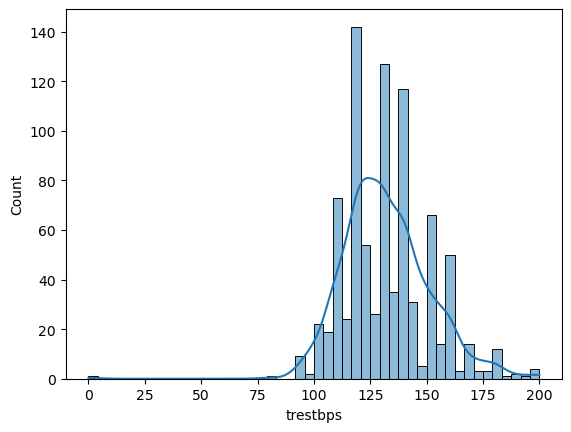

In [455]:
# create a histplot of trestbps column
sns.histplot(df['trestbps'],kde=True)

In [456]:
# Features with multiple categories (Nominal)
categorical_cols = ['dataset', 'cp', 'restecg', 'slope', 'thal', 'num']

# Features with only two possible values (Binary/Boolean)
bool_cols = ['sex', 'fbs', 'exang']

# Features with continuous or discrete numerical values
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

In [457]:
df.isnull().sum()   

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
target        0
dtype: int64

In [458]:
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)
missing_data_cols = df.isnull().sum()[df.isnull().sum() > 0].index.tolist()

In [459]:
# define the function to impute the missing values in thal column

def impute_categorical_missing_data(passed_col):
    
    df_null = df[df[passed_col].isnull()]
    df_not_null = df[df[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]
    
    other_missing_cols = [col for col in missing_data_cols if col != passed_col]
    
    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    if passed_col in bool_cols:
        y = label_encoder.fit_transform(y)
        
    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_classifier = RandomForestClassifier()

    rf_classifier.fit(X_train, y_train)

    y_pred = rf_classifier.predict(X_test)

    acc_score = accuracy_score(y_test, y_pred)

    print("The feature '"+ passed_col+ "' has been imputed with", round((acc_score * 100), 2), "accuracy\n")

    X = df_null.drop(passed_col, axis=1)

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass
                
    if len(df_null) > 0: 
        df_null[passed_col] = rf_classifier.predict(X)
        if passed_col in bool_cols:
            df_null[passed_col] = df_null[passed_col].map({0: False, 1: True})
        else:
            pass
    else:
        pass

    df_combined = pd.concat([df_not_null, df_null])
    
    return df_combined[passed_col]

def impute_continuous_missing_data(passed_col):
    
    df_null = df[df[passed_col].isnull()]
    df_not_null = df[df[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]
    
    other_missing_cols = [col for col in missing_data_cols if col != passed_col]
    
    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])
    
    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_regressor = RandomForestRegressor()

    rf_regressor.fit(X_train, y_train)

    y_pred = rf_regressor.predict(X_test)

    print("MAE =", mean_absolute_error(y_test, y_pred), "\n")
    print("RMSE =", root_mean_squared_error(y_test, y_pred), "\n")
    print("R2 =", r2_score(y_test, y_pred), "\n")

    X = df_null.drop(passed_col, axis=1)

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass
                
    if len(df_null) > 0: 
        df_null[passed_col] = rf_regressor.predict(X)
    else:
        pass

    df_combined = pd.concat([df_not_null, df_null])
    
    return df_combined[passed_col]

In [460]:
# impute missing values using our functions
for col in missing_data_cols:
    print("Missing Values", col, ":", str(round((df[col].isnull().sum() / len(df)) * 100, 2))+"%")
    if col in categorical_cols:
        df[col] = impute_categorical_missing_data(col)
    elif col in numeric_cols:
        df[col] = impute_continuous_missing_data(col)
    else:
        pass

Missing Values trestbps : 6.41%
MAE = 13.127109826589594 

RMSE = 17.004714460196983 

R2 = 0.09714816580098329 

Missing Values chol : 3.26%
MAE = 45.158202247191014 

RMSE = 63.78650717630501 

R2 = 0.6776881381528886 

Missing Values fbs : 9.78%
Missing Values restecg : 0.22%
The feature 'restecg' has been imputed with 66.3 accuracy

Missing Values thalch : 5.98%
MAE = 16.6985549132948 

RMSE = 21.801267595856146 

R2 = 0.3088810442552653 

Missing Values exang : 5.98%
Missing Values oldpeak : 6.74%
MAE = 0.5767558139534884 

RMSE = 0.8049346644004645 

R2 = 0.3827242624869296 

Missing Values slope : 33.59%
The feature 'slope' has been imputed with 69.92 accuracy

Missing Values ca : 66.41%
MAE = 0.6482258064516128 

RMSE = 0.8988298845111474 

R2 = 0.14140199059994463 

Missing Values thal : 52.83%
The feature 'thal' has been imputed with 72.41 accuracy



In [461]:
# Create boxplots for all numeric columns using plotly
fig = px.box(df, y=numeric_cols, points='outliers')
fig.update_layout(
    title='Boxplots of Numeric Columns',
    yaxis_title='Value',
    xaxis_title='Column',
    height=400,
    width=800
)
fig.show()

In [462]:
# Print the row from df where trestdps value is 0
df[df['trestbps'] == 0]

# remove this row from the data
df=df[df['trestbps']!=0]

In [463]:
# remove outliers in thalch and oldpeak and chol columns using IQR method
for col in ['thalch', 'oldpeak' , 'chol']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

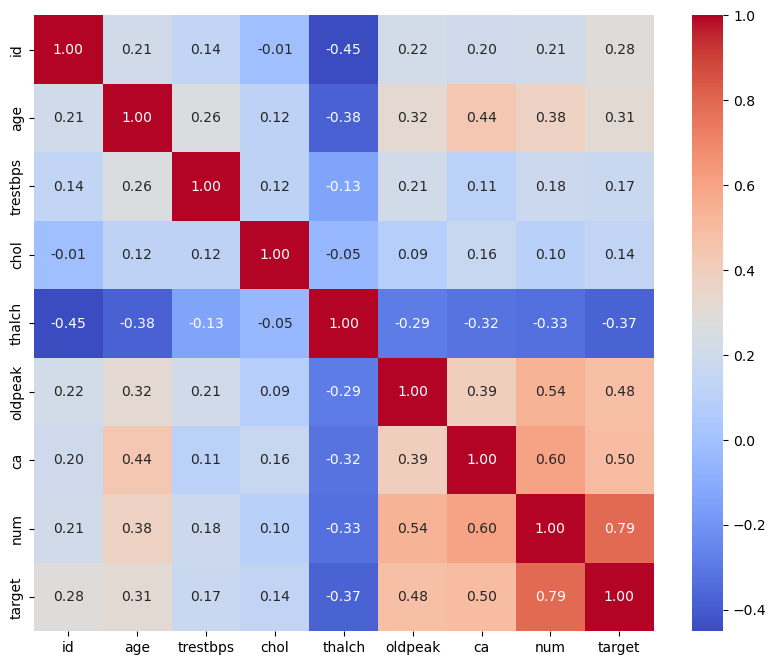

In [464]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()